# Includes code for creating current density profiles and how to extract the Fraunhofer from them. It also includes the opposite, given a Fraunhofer calculate the density profile. 
## The fact that it works can be achieved by creating a fake profile, getting the Fraunhofer and then getting back the profile. The method is just Fourier transform in one direction and then back. The FFT from Python works fine but the units are very hard to understang, making the integrals with the trapezoid method works best. Comparing them also helps to understand that they are both correct. 
## The final part is to extract the contour of real data. This is done by combining all the previous analysis. I extract the Ic of the data, then fit this to the phenomenological model and then extracting the current density that matches that given model. 
## The results are kind of expected, yielding purely edge states in the case of TB32 sample and yielding a mixture in the case of Ju1. Ju1 case is hard since it has all the magnetism. What I do is fit with the magnetism and then turn it off for the extraction 
## In order for everything to match the units are very important. I use mT, um and nA. 

## Import the modules you need and run the basic parameters which are called in general like font, color, etc. (this does not need to change between notebooks) 

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
import scipy
from scipy import signal
from scipy.fftpack import fft, ifft,fftfreq,fftshift
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
#import ipympl
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
from astropy.convolution import Gaussian1DKernel, convolve, Gaussian2DKernel

import time
from mpl_toolkits.mplot3d import Axes3D
import cmath
import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.ticker as mticker
#import exportDataToText_v8

from scipy.optimize import curve_fit

class Object():
    pass

savename='C:/Users/jdiez/LDQM/a. Data/Ju1/JJ_BF_2021/'

plt.rcParams["font.family"] = "arial"


## All the functions for plotting are in here

In [3]:
import LDQM_dataplot
import Superconductor_analysis
import TB32_Ic_analysis
import homemade_functions 
import JJ_current_distribution

savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savecount=1


orig_cmap = matplotlib.cm.RdBu_r
mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

font=16

def update_modules():
    
    importlib.reload(LDQM_dataplot)
    importlib.reload(Superconductor_analysis)
    importlib.reload(TB32_Ic_analysis)
    importlib.reload(homemade_functions)
    importlib.reload(JJ_current_distribution)

C:\jdiez_local\.jupyter\LDQM_dataplot.py:780: UserWarning: Trying to register the cmap 'shiftedcmap' which already exists.
  plt.register_cmap(cmap=newcmap)


In [4]:
update_modules()

from homemade_functions import runningMeanFast
from homemade_functions import plot_pre,plot_map,plot_line
from Superconductor_analysis import parula_cmap as parula
from Superconductor_analysis import derivative_dvdi, Ic_derivative 
from Superconductor_analysis import get_Ic_minimum, map_interpolation, magnJJ_bulk_edge,magnJJ_bulkedge
from Superconductor_analysis import get_Ic_maximums as get_Ic_max


# Creating Fraunhofers from current distributions 
## First make the current distribution
### I create first a simple square and a square edge state one. Then I can change this square for a edge states with Gaussians. This one is a more general creation formula, probably better. 
## Then do the integral for the Fraunhofer: The Fraunhofer is the integral of the Current distribution times a cosine function. it is somehting like the real part of the Fourier transform of the current distribution 

In [5]:
x=np.linspace(-1,1,301)
def square(x,l,jc=1):
    '''l would be the dying SC around the edges'''
    ls=(x[-1]-x[0])/len(x) ## interval of points in the junction
    ly=int(l/ls)-1  ## the number of points in the decaying region
    y=np.zeros_like(x)
    for i in range(ly,len(x)-ly):
        y[i]=jc
    y[0:ly]=np.linspace(0,jc,ly)
    y[len(x)-ly:]=np.linspace(jc,0,ly)
    return y

def edges(x,ratio,edge_position,edge_w,jc=1):
    '''l would be the edge size here'''
    ls=(x[-1]-x[0])/len(x)  ## interval of points in the junction
    ly1=int(edge_position/ls)-1  ## the number of points in the decaying region, lets do it same for edge outside to edge inside
    ly2=int(edge_w/ls)-1
    bulkvalue=1*ratio*jc
    edgevalue=1*(1-ratio)*jc
    y=np.zeros_like(x)
    ## Now fill the bulk of the junction 
    for i in range(2*ly1+ly2,len(x)-(2*ly1+ly2)):
        y[i]=bulkvalue
    ## Now fill the edges 
    for i in range(ly1,ly1+ly2):
        y[i]=edgevalue
    for i in range(len(x)-(2*ly1+ly2),len(x)-(ly1)):
        y[i]=edgevalue
    ## Finally interpolate the decays 
    ### First to the outside
    y[0:ly1]=np.linspace(0,edgevalue,ly1)
    y[len(x)-ly1:]=np.linspace(edgevalue,0,ly1)
    ### Then to the inside 
    y[ly1+ly2:2*ly1+ly2]=np.linspace(edgevalue,bulkvalue,ly1)
    y[len(x)-2*ly1-ly2:len(x)-ly1-ly2]=np.linspace(bulkvalue,edgevalue,ly1)
    
    return y

def asym_edges(x,ratio,edge_position,ratio2,edge_w,edge_w2,jc=1):
    '''l would be the edge size here
    ratio is a number between 1 and 0
    edgeratio is a number between 1 and 0
    '''
     ## interval of points in the junction
    ls=(x[-1]-x[0])/len(x) 
    ## the number of points in the decaying region, lets do it same for edge outside to edge inside
    ly1=int(edge_position/ls)-1  
    ly2=int(edge_w/ls)-1
    ly3=int(edge_w2/ls)-1
    bulkvalue=ratio*jc
    edgevalue=(1-ratio)*jc
    edgevalue1=edgevalue*ratio2
    edgevalue2=edgevalue*(1-ratio2)
    y=np.zeros_like(x)
    ## Now fill the bulk of the junction 
    for i in range(2*ly1+ly2,len(x)-(2*ly1+ly2)):
        y[i]=bulkvalue
    ## Now fill the edges 
    ### First the left edge
    for i in range(ly1,ly1+ly2):
        y[i]=edgevalue1
    ### Then the right edge
    for i in range(len(x)-(2*ly1+ly3),len(x)-(ly1)):
        y[i]=edgevalue2
    ## Finally interpolate the decays 
    ### First to the outside
    y[0:ly1]=np.linspace(0,edgevalue1,ly1)
    y[len(x)-ly1:]=np.linspace(edgevalue2,0,ly1)
    ### Then to the inside 
    y[ly1+ly2:2*ly1+ly2]=np.linspace(edgevalue1,bulkvalue,ly1)
    y[len(x)-2*ly1-ly3:len(x)-ly1-ly3]=np.linspace(bulkvalue,edgevalue2,ly1)
    
    return y

def normal_dist(x , mean , sd):
    '''Gaussian function, used to localize the edge states'''
    prob_density = (np.pi*sd) * np.exp(-0.5*((x-mean)/sd)**2)
    return prob_density

def Js_func(x,ratio,edge_position,edge_w=0,edge_ratio=0.5):
    '''Make general shapes of current densities having edge states and bulk distributions
    and different ratios of these distributions 
    Ratio only makes sense if it is below 0.5 '''
    js=np.zeros_like(x)
    ## Transform the distance into number of points 
    xint=(x[-1]-x[0])/len(x) ## interval of points in the junction
    bulkvalue=1*ratio
    
    decay_len_points=int((edge_position)/xint)-1
    if ratio>0.5:
        edgevalue=bulkvalue
    else:
        edgevalue=1-ratio
        
    edgevalue1=edgevalue*edge_ratio*2
    edgevalue2=edgevalue*(1-edge_ratio)*2
    
    maxGaussian=np.amax(normal_dist(x,0,edge_w))
    Gaussian1=normal_dist(x,x[0]+edge_position,edge_w)/maxGaussian*edgevalue1
    Gaussian2=normal_dist(x,x[-1]-edge_position,edge_w)/maxGaussian*edgevalue2
        
    if ratio<0.5:
        for i in range(decay_len_points,len(x)):
            if Gaussian1[i]<=bulkvalue:
                decay_len_points=i
                break
            else:
                decay_len_points=int(len(x)/2)
                
    for i in range(10,decay_len_points):
        js[i]=Gaussian1[i]
    for i in range(len(x)-decay_len_points,len(x)-10):
        js[i]=Gaussian2[i]
     
    for i in range(decay_len_points,len(x)-decay_len_points):
        js[i]=bulkvalue 
    js[0:10]=np.linspace(0,js[10],10)
    js[-10:]=np.linspace(js[10],0,10)
    return js



In [6]:
x=np.linspace(-1,1,301)
def square_exp(x,decay_l,decay_rate,jc=1,):
    '''l would be the dying SC around the edges'''
    ls=(x[-1]-x[0])/len(x) ## interval of points in the junction
    ly=int(decay_l/ls)-1  ## the number of points in the decaying region
    j=np.zeros_like(x)
    ''' The bulk will all have the same distribution '''
    for i in range(ly,len(x)-ly):
        j[i]=jc
    j[0:ly]=exp_decay(-x[0:ly],decay_rate)
    j[len(x)-ly:]=exp_decay(x[len(x)-ly:],decay_rate)
    return j

In [7]:
def exp_decay(x,tau):
    return np.exp(-x*tau)/np.amax(np.exp(-x*tau))

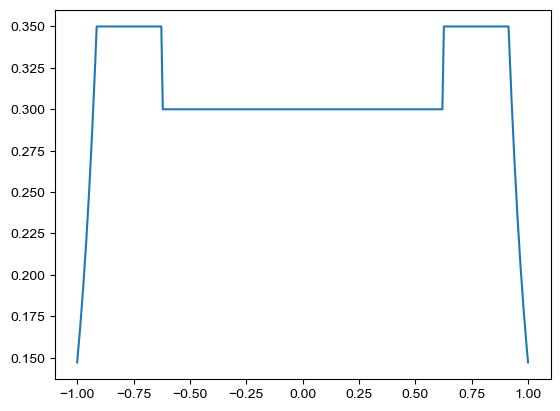

In [8]:

'''
Making the current density distribution in real space
Changing the ratio, edge_ratio allows you to have bulk or edge conduction or both
'''
def edges_exp(x,edge_w,ratio,edgeratio,decay_l,decay_rate,edgew2=0,jc=1,):
    '''l would be the dying SC around the edges'''
    ls=(x[-1]-x[0])/len(x) ## interval of points in the junction
    ly=int(decay_l/ls)-1  ## the number of points in the decaying region
    ledge=int(edge_w/ls)-1 ## number of points in the edge region
    edge_start=decay_l
    edge_end=decay_l+edge_w
    j=np.zeros_like(x)
    J_bulk=jc*ratio
    J_edge1=jc*(1-ratio)*edgeratio
    J_edge2=jc*(1-ratio)*(1-edgeratio)
    if edgeratio==1:
        J_edge1=J_bulk
        J_edge2=J_bulk
    ''' The bulk will all have the same distribution '''
    for i in range(ly+ledge+ly,len(x)-ly-ledge-ly):
        j[i]=J_bulk
    '''Now make the edges'''
    for i in range(ly,ly+ledge):
        j[i]=J_edge1
    j[0:ly]=exp_decay(-x[0:ly],decay_rate)*J_edge1
    j[ly+ledge:ly+ledge+ly]=exp_decay(x[ly+ledge:ly+ledge+ly],decay_rate)*J_edge1+J_bulk
    for i in range(ly+ledge,ly+ledge+ly):
        if j[i]>J_edge1:
            j[i]=J_edge1
        
    '''Right edge'''
    for i in range(len(x)-ly-ledge,len(x)-ly):
        j[i]=J_edge2
    
    j[len(x)-ly-ledge-ly:len(x)-ledge-ly]=exp_decay(-x[len(x)-ly-ledge-ly:len(x)-ledge-ly],decay_rate)*J_edge2+J_bulk
    j[len(x)-ly:]=exp_decay(x[len(x)-ly:],decay_rate)*J_edge2
    
    for i in range(len(x)-ly-ledge-ly,len(x)-ledge-ly):
        if j[i]>J_edge2:
            j[i]=J_edge2
    return j

'''Plot the results'''
x=np.linspace(-1,1,301)
plt.plot(x,edges_exp(x,0.2,0.3,0.5,0.1,10))

In [25]:
def int_Js_brokenT(Js,B,x,edge_l,l,varphi1,varphi2,varphi3,t=0.25,Ic=1,edge_phase=0.5):
    '''
    Js would be the real space current density (obtained by edges_exp)
    This code will give a general equation to integrate to obtain the actual current density 
    edge_phase determines whether you take into account the decay with the phase or not 
    '''
    left_edge_st=x[0]+edge_phase*l
    left_edge_end=x[0]+edge_l+(1-edge_phase)*l
    right_edge_st=x[-1]-edge_l-(1-edge_phase)*l
    right_edge_end=x[-1]-edge_phase*l
    data=np.zeros_like((x),dtype='complex_')
    for i in range(len(x)):
        if x[i]<left_edge_end and x[i]>left_edge_st:
            beta=2*np.pi*t*(B+varphi1)/phi0   
        elif x[i]<right_edge_end and x[i]>right_edge_st:
            beta=2*np.pi*t*(B+varphi2)/phi0
        else:
            beta=2*np.pi*t*(B+varphi3)/phi0
            
        data[i]=Js[i]*np.exp(1j*beta*x[i])*Ic
        
    return data

## Fraunhofer patterns and Jc formulas to use in the integrations 
## In the end I always use the last one, the int_Js and integrate that complex whole thing

In [11]:
'''
The units are going to be given in mT, nA and um 
'''
phi0=2.067833848 ## Units given in mTum^2

def Fr_bulk(x,l,B,t,jc=1):
    return square(x,l,jc)*np.cos(2*np.pi*B*x*t/phi0)

def Fr_edge(x,l1,l2,ratio,B,t,jc=1):
    return edges(x,ratio,l1,l2,jc)*np.cos(2*np.pi*B*x*t/phi0)

def Fr_asym_edge(x,l1,l2,ratio,B,t,edgeratio,jc=1):
    
    return asym_edges(x,ratio,l1,edgeratio,l2,l2,jc)*np.cos(2*np.pi*B*x*t/phi0)

def Fr_general(x,ratio,edge_position,edge_w,B,t,jc=1):
    return Js_func(x,ratio,edge_position,edge_w)*np.cos(2*np.pi*B*x*t/phi0)

def int_Js(Js,beta,x):
    return Js*np.exp(1j*beta*x)



## Prove that everything works. Create a Jc(x), extract the Fraunhofer. Use this Fraunhofer to extract back the Jc(x). 

## Plot the PDF files and save it 

In [12]:
savename='C:/jdiez_local/LDQM/g. Manuscript/Figures_2022/'

In [192]:
savecount=1

In [1030]:
savecount=0

### Fig S13 of the paper. The parameters to obtain the different plots just change the amount of current through edge or bulk. The next three blocks are such plots of Fig. s13


In [12]:
integral2=[]
if savecount==0:
    save=True
else:
    save=False
x=np.linspace(-0.5,0.5,601)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,401)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.025
edge_l=0.025

ratio=0
Ic=2

jc2=4
edgeratio=0.5
phase1=0
phase2=0
phase3=0
beta=2*np.pi*t*B/phi0

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,250,0,Ic)
#Jsx=square_exp(x,l,100,Ic)
#Jsx=asym_edges(x,ratio,l,edgeratio,l2,l2,jc1)
# This is an integral in x, so I run everything over B
for i in B:
    #integral2.append(np.abs(np.trapz(Fr_asym_edge(x,l,l2,ratio,i,t,edgeratio,jc2),x)))

    int_trap=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,phase1,phase2,phase3,t,Ic),x)
    #integral2.append(np.abs(int_trap))
    integral2.append(cmath.sqrt((int_trap.real)**2+(int_trap.imag)**2))
    
ax=plot_pre(6,4)
ax.plot(B,integral2/np.amax(integral2),'k')
plot_line(ax,leg=False)
if save:
    plt.savefig(savename+'Fraunhfoer_edge_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Fraunhofer_edge_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()

ax=plot_pre(6,4)
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax.set_ylim(0,1.05)
if save:
    plt.savefig(savename+'edge_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'edge_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()



NameError: name 'int_Js_brokenT' is not defined

In [13]:
integral2=[]
if savecount==0:
    save=True
else:
    save=False
x=np.linspace(-0.5,0.5,601)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,401)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=2.3

jc2=4
edgeratio=0.5
phase1=0
phase2=0
phase3=0
beta=2*np.pi*t*B/phi0

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,120,0,Ic)
#Jsx=square_exp(x,l,100,Ic)
#Jsx=asym_edges(x,ratio,l,edgeratio,l2,l2,jc1)
# This is an integral in x, so I run everything over B
for i in B:
    #integral2.append(np.abs(np.trapz(Fr_asym_edge(x,l,l2,ratio,i,t,edgeratio,jc2),x)))

    int_trap=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,phase1,phase2,phase3,t,Ic),x)
    #integral2.append(np.abs(int_trap))
    integral2.append(cmath.sqrt((int_trap.real)**2+(int_trap.imag)**2))
    
ax=plot_pre(6,4)
ax.plot(B,integral2/np.amax(integral2),'k')
plot_line(ax,leg=False)
if save:
    plt.savefig(savename+'Fraunhfoer_bulkedge_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Fraunhfoer_bulkedge_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()

ax=plot_pre(6,4)
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax.set_ylim(0,1.1)
if save:
    plt.savefig(savename+'bulkedge_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'bulkedge_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()


NameError: name 'int_Js_brokenT' is not defined

In [14]:
integral2=[]
if savecount==0:
    save=True
else:
    save=False
x=np.linspace(-0.5,0.5,601)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,401)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=1

jc2=4
edgeratio=0.5
phase1=0
phase2=0
phase3=0
beta=2*np.pi*t*B/phi0

#Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,120,0,Ic)
Jsx=square_exp(x,l,100,Ic)
#Jsx=asym_edges(x,ratio,l,edgeratio,l2,l2,jc1)
# This is an integral in x, so I run everything over B
for i in B:
    #integral2.append(np.abs(np.trapz(Fr_asym_edge(x,l,l2,ratio,i,t,edgeratio,jc2),x)))

    int_trap=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,phase1,phase2,phase3,t,Ic),x)
    #integral2.append(np.abs(int_trap))
    integral2.append(cmath.sqrt((int_trap.real)**2+(int_trap.imag)**2))
    
ax=plot_pre(6,4)
ax.plot(B,integral2/np.amax(integral2),'k')
plot_line(ax,leg=False)
if save:
    plt.savefig(savename+'Fraunhfoer_bulk_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Fraunhofer_bulk_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()

ax=plot_pre(6,4)
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
ax.set_ylim(0,1.05)
if save:
    plt.savefig(savename+'bulk_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'bulk_Jcs_decay'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1
plt.show()


NameError: name 'int_Js_brokenT' is not defined

## Make a map of this by adding the DOS of a SC

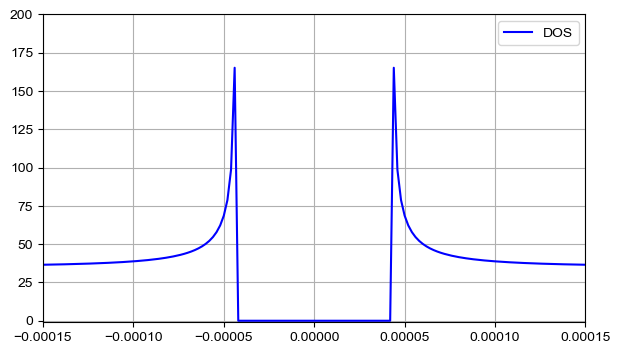

In [16]:
e=1.602E-19
V=np.arange(-0.2E-3,0.2E-3,0.2E-5)
Tsme=np.zeros_like(V)
E=e*V
Delta=43E-6
k=8.61E-5
#k=1.380649E-23
N0=1
T=1
tau=15E-6
Is=35
DOSV=np.zeros_like(V)
for i in range(len(V)):
    Tsme[i]=2*k*T
    if abs(V[i])>Delta:
        DOSV[i]=V[i]
        
def expT(T,V):
    return np.exp(-Delta/(k*T))*np.sqrt(2*np.pi*Delta/(k*T))*np.abs(V)


def Ns(E):
    return Is*(np.abs(E)/np.sqrt(np.abs((E)**2-Delta**2)))/N0


    #return (np.abs(V)/np.sqrt(np.abs(V**2-Delta**2)))/N0*np.sqrt(2*np.pi*Delta/(k*T))
def dIdV(V):
    return Ns(V)*np.exp(-Delta/(k*T))

# convolute with a gaussian, this accounts for the finite temperature
#package used is astropy.convolution
#extend in convolve keeps the boundaries to have the same value as if the extended
#gaussian there is just the same as 

def gaussian(x,nu,s):
    return 1./(s*np.sqrt(2*np.pi))*np.exp(-0.5*np.power(x-nu,2)/np.power(s,2))

c=1

g=Gaussian1DKernel(stddev=c)


#convoluted=convolve(data,g,boundary='extend')
convoluted=convolve(Ns(DOSV),g,boundary='extend')

def Ns_dynes(E):
    return Is*np.real((np.abs(E-1j*tau)/np.sqrt(np.abs((E-1j*tau)**2-Delta**2)))/N0)

convoluted2=np.convolve(Ns_dynes(DOSV),g,mode='same')

plt.figure(figsize=(7,4))
plt.plot(V,Ns(DOSV),'b',label='DOS')
#plt.plot(V,convoluted,'k',label='DOS Thermal')
#plt.plot(V,convoluted2,'r',label='DOS Thermal & Dynes')

#plt.plot(V,g,'r',label='DOS Thermal & Dynes')
#plt.xlabel('V (mV)',fontsize=14)
#plt.ylabel('$I_S$',fontsize=14)
plt.legend()
plt.ylim(-1,200)
plt.xlim(-0.00015,0.00015)
plt.grid()
plt.show()


In [17]:
V=np.linspace(-0.5,0.5,401)
B=np.linspace(-80,80,601)
DOSV=np.zeros((len(V),len(B)))
Tsme=np.zeros_like(V)
for i in range(len(V)):
    for j in range(len(integral2)):
        Tsme[i]=2*k*T
        if abs(V[i])>integral2[j]:
            DOSV[i,j]=V[i]
convoluted=[]
for i in range(len(DOSV)):
    convoluted.append(convolve(Ns(DOSV)[i],g,boundary='extend'))
    
def Ns2D(E,Delta):
    data=np.zeros_like((DOSV))
    conv_data=np.zeros_like((data))
    for i in range(len(E)):
        for j in range(len(Delta)):
            data[i,j]=Is*(np.abs(E[i,j])/np.sqrt(np.abs((E[i,j])**2-(Delta[j])**2)))/N0
    return data

def dIdV(V,Delta):
    dIdV_data=np.zeros_like((DOSV))
    Nsdata=np.asarray(Ns2D(V,Delta))
    for i in range(len(dIdV_data)):
        for j in range(len(Delta)):
            dIdV_data[i,j]=Nsdata[i,j]*np.exp(-Delta[j]*1E-6/(k*T))   
    return dIdV_data
c=5
g=Gaussian1DKernel(stddev=c)

#convoluted=convolve(data,g,boundary='extend')
def conv_thermal(E,Delta):
    conv_data=[]
    NsData=np.transpose(Ns2D(DOSV,integral2))
    for i in range(len(NsData)):
        conv_data.append(convolve(NsData[i],g,boundary='extend'))
    conv_data=np.transpose(conv_data)
    return conv_data

def Ns2D_IAsym(V,Icplus,Icminus):

    E=np.zeros((len(V),len(B)))
    data=np.zeros_like((E))
    Tsme=np.zeros_like(V)
    for i in range(len(V)):
        for j in range(len(Icplus)):
            Tsme[i]=2*k*T
            if V[i]>=0:
                if abs(V[i])>Icplus[j]:
                    E[i,j]=V[i]
            elif V[i]<0:
                if abs(V[i])>Icminus[j]:
                    E[i,j]=V[i]

    for i in range(len(V)):
        if V[i]>=0:
            for j in range(len(Icplus)):
                data[i,j]=Is*(np.abs(E[i,j])/np.sqrt(np.abs((E[i,j])**2-Icplus[j]**2)))/N0
        else:
            for j in range(len(Icplus)):
                data[i,j]=Is*(np.abs(E[i,j])/np.sqrt(np.abs((E[i,j])**2-Icminus[j]**2)))/N0
  
    return data

## Device A For Fig 2
### Dont touch this

In [659]:
2.067/0.8/0.250

10.335

In [847]:
1.38E-23*300/1.602E-19

0.025842696629213485

In [848]:
1.602E-19/1.38E-23*1E-3

11.608695652173912

In [849]:
np.exp(-1)

0.36787944117144233

In [855]:
savecount=1

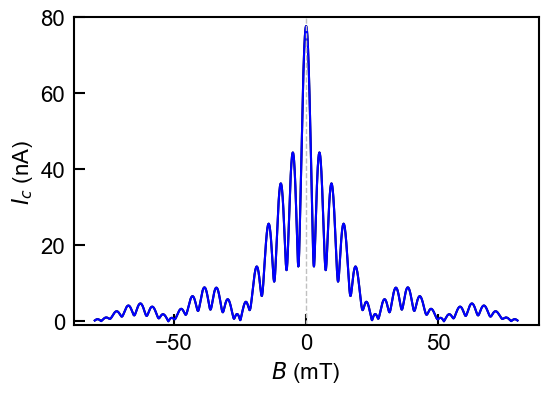

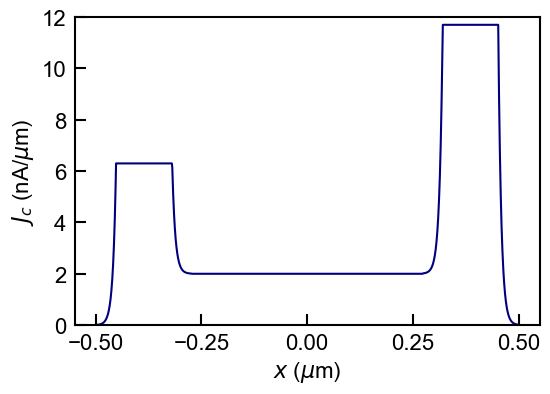

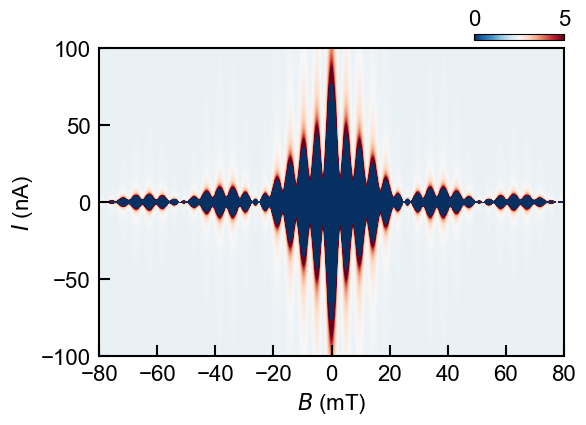

In [34]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
if savecount==0:
    save=True
else:
    save=False


x=np.linspace(-0.5,0.5,1001)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,1001)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=20

edgeratio=0.35

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,140,0,Ic)

#Jsx=square_exp(x,l,50)
edge_p=0
Icplus=[]
Icminus=[]

I_asym=False
text_true=False
glob_phase=0
phase1=0
phase2=0
phase3=0
phase4=phase1
phase5=phase2
phase6=phase3

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B

for i in B:
    
    ## Obtain the complex current density 
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase1,glob_phase+phase2,glob_phase+phase3,t,Ic,edge_p),x)
    
    ## Calculate the modulus of the complex integral
    modulus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)

    Icplus.append(modulus )  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase-phase1,glob_phase-phase2,glob_phase-phase3,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase4,glob_phase+phase5,glob_phase+phase6,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )

## Plot the results 
ax=plot_pre(6,4)
ax.plot(B,Icplus,'k')
ax.plot(B,np.abs(Icminus),'b')
ax.axvline(x=0,linestyle='dashed',color='silver',linewidth=1)
plot_line(ax,leg=False)
ax.set_ylim(-1,80)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre(6,4)
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,12)
ax.set_xlim(-0.55,0.55)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.25))
if save:
    plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1 

plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(6,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
#ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
if text_true:
    ax.text(20,40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
    ax.text(20,60,r'$\psi_{right}(I>0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
    ax.text(20,80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
    if I_asym==True:
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(-phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(-phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(-phase3/np.pi),fontsize=font-3)
    else:  
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
#ax.axvline(x=0,linestyle='dashed',color='k',linewidth=1)
if save:
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

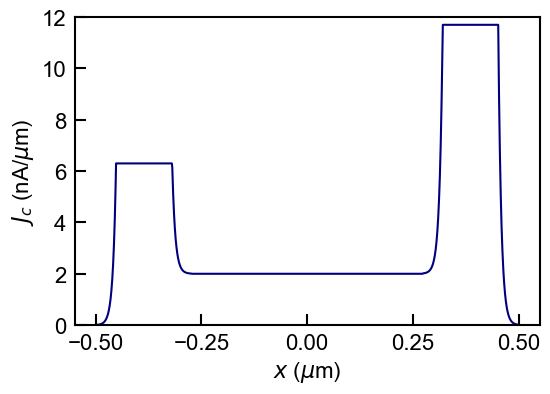

In [33]:
ax=plot_pre(6,4)
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,12)
ax.set_xlim(-0.55,0.55)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.5))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.25))
if save:
    plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1 

plt.show()

## Device A SC/N/SC data

C:\jdiez_local\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


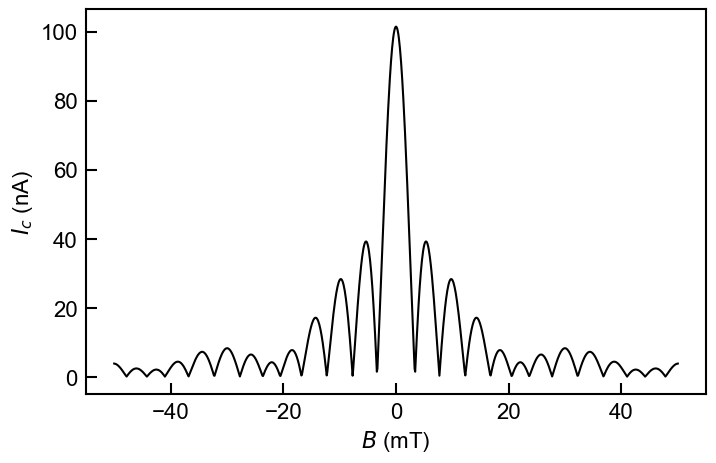

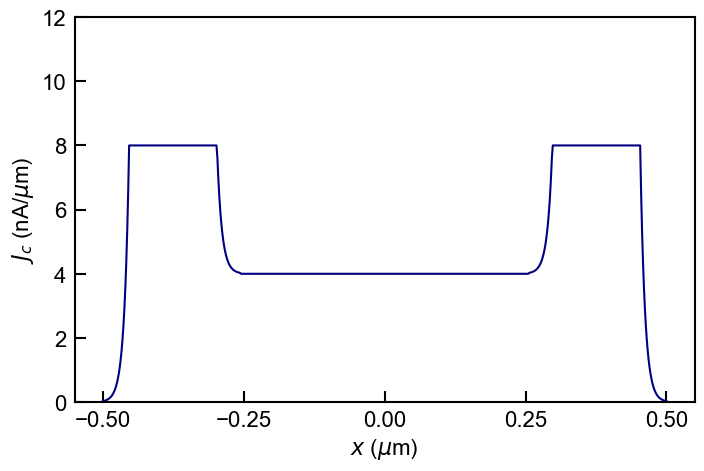

C:\jdiez_local\.jupyter\LDQM_dataplot.py:780: UserWarning: Trying to register the cmap 'shiftedcmap' which already exists.
  plt.register_cmap(cmap=newcmap)


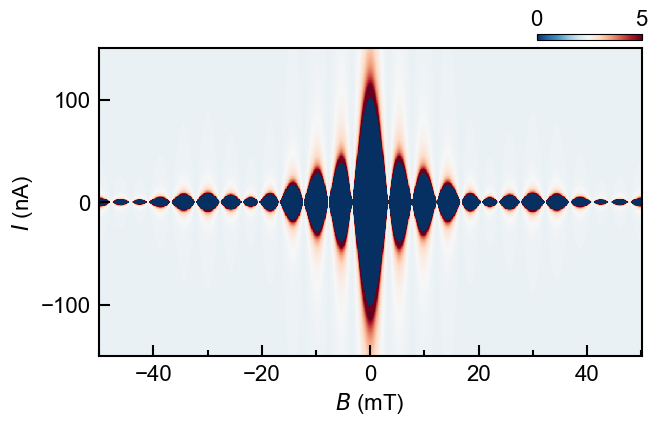

In [28]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
if savecount==0:
    save=True
else:
    save=False
text_true=False
integral=[]

x=np.linspace(-0.5,0.5,601)
B=np.linspace(-50,50,1001)

V=np.linspace(-150,150,401)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
#t=0.25
l=0.05
edge_l=0.1

ratio=0.2
Ic=20

jc2=15
edgeratio=0.5

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,120,0,Ic)

#Jsx=square_exp(x,l,120,Ic)
    
Icplus=[]
Icminus=[]
I_asym=True
phase1=0
phase2=0
phase3=0

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B

for i in B:
    
    ## Obtain the complex current density 
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,phase1,phase2,phase3,t,Ic),x)
    
    ## Calculate the modulus of the complex integral
    modulus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)

    Icplus.append(modulus )  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,-phase1,-phase2,-phase3,t,Ic),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        Icminus.append(modulus)

## Plot the results 
ax=plot_pre()
ax.plot(B,Icplus,'k')
plot_line(ax,leg=False)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre()
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
#ax.axvline(x=x[0]+edge_l+l)
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,12)
ax.set_xlim(-0.55,0.55)
#ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.25))
if save:
    plt.savefig(savename+'EdgeBulkAsymJs_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'EdgeBulkAsymJs_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1 

plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(7,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
#ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
if text_true:
    ax.text(20,40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
    ax.text(20,60,r'$\psi_{right}(I>0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
    ax.text(20,80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
    if I_asym==True:
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(-phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(-phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(-phase3/np.pi),fontsize=font-3)
    else:  
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
if save:
    #plt.savefig(savename+'EdgeBulkAsym_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    #plt.savefig(savename+'EdgeBulkAsym_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

In [21]:
savename='C:/jdiez_local/LDQM/g. Manuscript/Figures_2022/'

## Device B - Fig 2
### Dont touch this

In [29]:
savecount=1

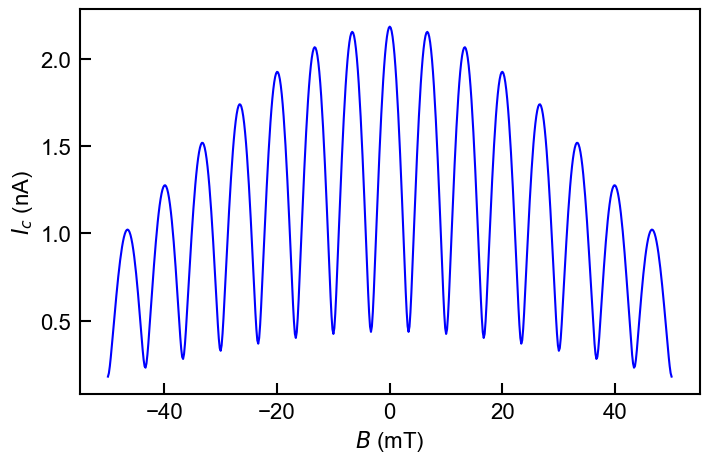

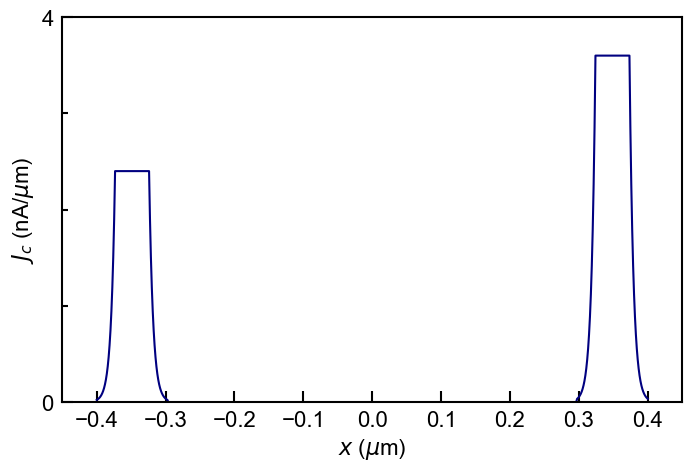

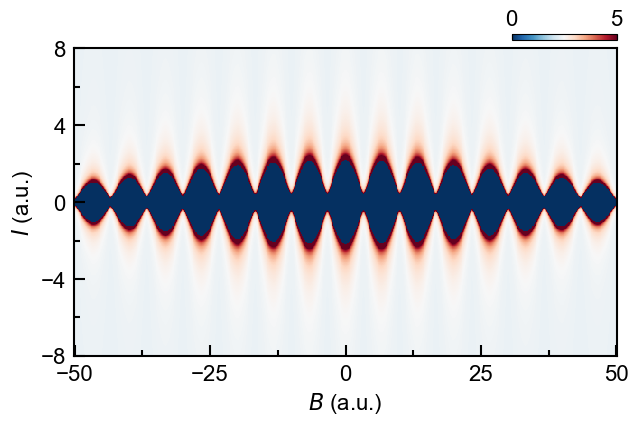

In [31]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
integral=[]

x=np.linspace(-0.4,0.4,601)
B=np.linspace(-50,50,601)

V=np.linspace(-8,8,401)
DOSV=np.zeros((len(V),len(B)))

if savecount==0:
    save=True
else:
    save=False 
t=0.8/1.8
l=0.03
edge_l=0.05
edge_l2=0.05
ratio=0.0
Ic=6
jc2=2
edgeratio=0.4

Jsx=edges_exp(x,edge_l,ratio,edgeratio,l,175,0,Ic)
I_asym=False
phase1=0
phase2=0
phase3=0

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B
for i in B:
    
    ## Obtain the complex current density 
    
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,phase1,phase2,phase3,t,Ic),x)
    
    ## Calculate the modulus of the complex integral

    mod_plus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)
    Icplus.append(mod_plus )  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,-phase1,-phase2,-phase3,t,Ic),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        Icminus.append(mod_plus)

## Plot the results 
ax=plot_pre()
ax.plot(B,Icplus,'b')
plot_line(ax,leg=False)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre()
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
#ax.axvline(x=x[0]+edge_l+l)
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,4)
ax.set_xlim(-0.45,0.45)
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(4))
if save:
    plt.savefig(savename+'EdgeAsymJs_Fraunhofer_REalSize'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'EdgeAsymJs_Fraunhofer_RealSize'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(7,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (a.u.)',fontsize=font)
ax.set_xlabel('$B$ (a.u.)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
'''
ax.text(20,0.3,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
ax.text(20,0.4,r'$\psi_{right}(I>0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
if I_asym==True:
    ax.text(20,-0.4,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(-phase1/np.pi),fontsize=font-3)
    ax.text(20,-0.3,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(-phase2/np.pi),fontsize=font-3)
else: 
    ax.text(20,-0.4,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
    ax.text(20,-0.3,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
'''
ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(12.5))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(25))
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(4))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
if save:
    #plt.savefig(savename+'EdgeBulk_Fraunhofer_RealSize'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    #plt.savefig(savename+'EdgeBulk_Fraunhofer_RealSize'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

In [1176]:
savecount=0

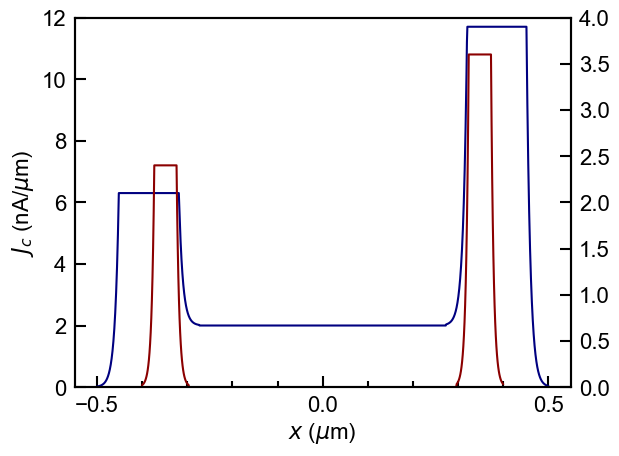

In [1178]:
## Things of device B 

if savecount==0:
    save=True
else:
    save=False
x=np.linspace(-0.4,0.4,601)
B=np.linspace(-50,50,601)

V=np.linspace(-8,8,401)
DOSV=np.zeros((len(V),len(B)))


t=0.8/1.8
l=0.03
edge_l=0.05
edge_l2=0.05
ratio=0.0
Ic=6
jc2=2
edgeratio=0.4

Jsx=edges_exp(x,edge_l,ratio,edgeratio,l,175,0,Ic)

## Things of device A
2
x2=np.linspace(-0.5,0.5,1001)
B2=np.linspace(-80,80,2001)

V2=np.linspace(-100,100,1001)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=20

edgeratio=0.35

Jsx2=edges_exp(x2,edge_l+l,ratio,edgeratio,l,120,0,Ic)

fig,ax=plt.subplots()
#ax.plot(x,Jsx,'navy')
ax.plot(x2,Jsx2,'navy')

#ax.axvline(x=x[0]+edge_l+l)
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
#ax.set_ylim(0,12)
ax.set_xlim(-0.55,0.55)
ax.set_ylim(0,12)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.1))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
ax2=ax.twinx()
ax2.plot(x,Jsx,'darkred')
plot_line(ax2,xlabel='',ylabel='',leg=False)
ax2.set_ylim(0,4)
if save:
    plt.savefig(savename+'Jcx_together'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'Jcx_together'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

# Broken T, just change the phases as in the Figure
## Dont change the rest

## The way to make it as the original ones is to take most of the edges as the phase, including the decay 
## i think this is not either correct or not, since it is mostly a "idea"simulation 


In [24]:
def int_Js_brokenT(Js,B,x,edge_l,l,varphi1,varphi2,varphi3,t=0.25,Ic=1,edge_phase=0.5):
    '''
    Js would be the real space current density (obtained by edges_exp)
    This code will give a general equation to integrate to obtain the actual current density 
    edge_phase determines whether you take into account the decay with the phase or not 
    '''
    left_edge_st=x[0]+edge_phase*l
    left_edge_end=x[0]+edge_l+(1-edge_phase)*l
    right_edge_st=x[-1]-edge_l-(1-edge_phase)*l
    right_edge_end=x[-1]-edge_phase*l
    data=np.zeros_like((x),dtype='complex_')
    for i in range(len(x)):
        if x[i]<left_edge_end and x[i]>left_edge_st:
            beta=2*np.pi*t*(B+varphi1)/phi0   
        elif x[i]<right_edge_end and x[i]>right_edge_st:
            beta=2*np.pi*t*(B+varphi2)/phi0
        else:
            beta=2*np.pi*t*(B+varphi3)/phi0
            
        data[i]=Js[i]*np.exp(1j*beta*x[i])*Ic
        
    return data

In [38]:
savecount=1

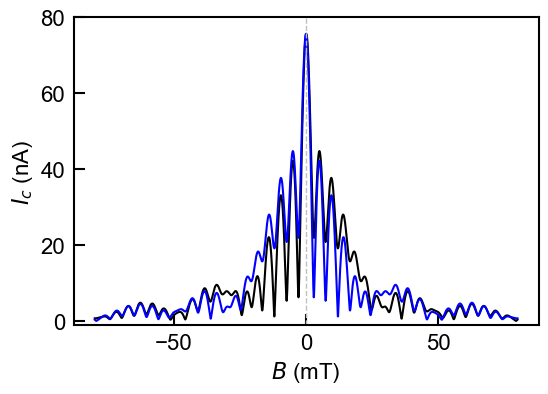

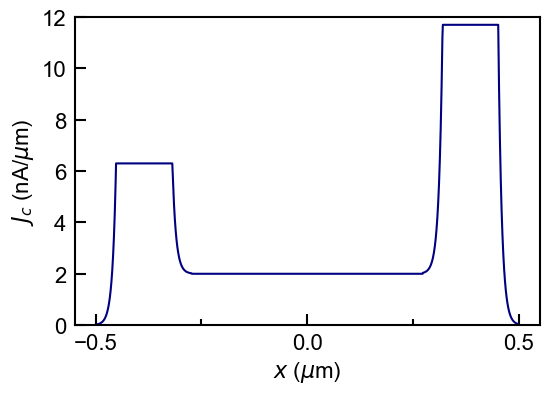

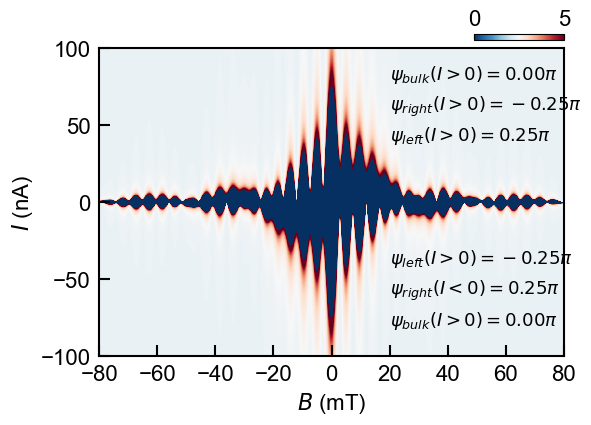

In [37]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
if savecount==0:
    save=True
else:
    save=False


x=np.linspace(-0.5,0.5,1001)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,1001)
DOSV=np.zeros((len(V),len(B)))


t=1/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=20

edgeratio=0.35

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,120,0,Ic)

#Jsx=square_exp(x,l,50)
edge_p=0
Icplus=[]
Icminus=[]

I_asym=True
text_true=True

glob_phase=0
phase1=np.pi/4
phase2=-np.pi/4
phase3=0
phase4=phase1
phase5=phase2
phase6=phase3

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B

for i in B:
    
    ## Obtain the complex current density 
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase1,glob_phase+phase2,glob_phase+phase3,t,Ic,edge_p),x)
    
    ## Calculate the modulus of the complex integral
    modulus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)

    Icplus.append(modulus )  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase-phase1,glob_phase-phase2,glob_phase-phase3,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase4,glob_phase+phase5,glob_phase+phase6,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )

## Plot the results 
ax=plot_pre(6,4)
ax.plot(B,Icplus,'k')
ax.plot(B,np.abs(Icminus),'b')
ax.axvline(x=0,linestyle='dashed',color='silver',linewidth=1)
plot_line(ax,leg=False)
ax.set_ylim(-1,80)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre(6,4)
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,12)
ax.set_xlim(-0.55,0.55)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
#if save:
    #plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    #plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    #savecount=savecount+1 

plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(6,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
#ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
if text_true:
    ax.text(20,40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
    ax.text(20,60,r'$\psi_{right}(I>0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
    ax.text(20,80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
    if I_asym==True:
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(-phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(-phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(-phase3/np.pi),fontsize=font-3)
    else:  
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
#ax.axvline(x=0,linestyle='dashed',color='k',linewidth=1)
if save:
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

## Change the size of the Hall bar slightly

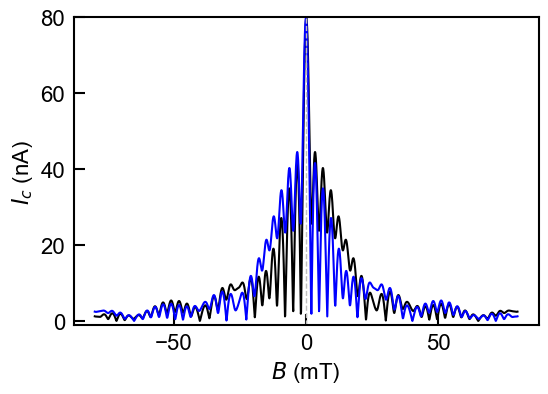

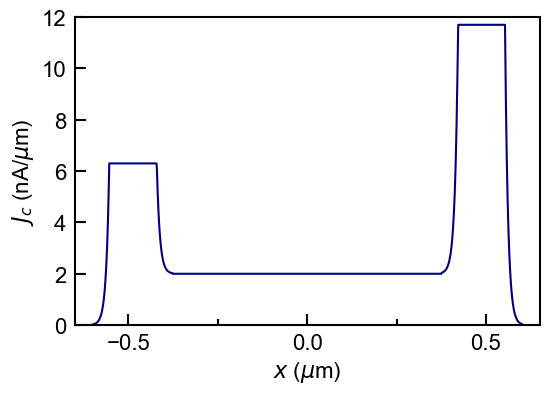

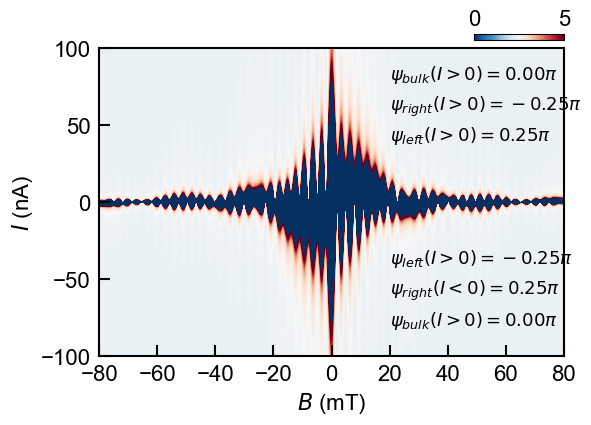

In [42]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
if savecount==0:
    save=True
else:
    save=False


x=np.linspace(-0.6,0.6,1001)
B=np.linspace(-80,80,2001)

V=np.linspace(-100,100,1001)
DOSV=np.zeros((len(V),len(B)))


t=1.2/1.8
l=0.05
edge_l=0.08

ratio=0.1
Ic=20

edgeratio=0.35

Jsx=edges_exp(x,edge_l+l,ratio,edgeratio,l,120,0,Ic)

#Jsx=square_exp(x,l,50)
edge_p=0
Icplus=[]
Icminus=[]

I_asym=True
text_true=True

glob_phase=0
phase1=np.pi/4
phase2=-np.pi/4
phase3=0
phase4=phase1
phase5=phase2
phase6=phase3

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B

for i in B:
    
    ## Obtain the complex current density 
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase1,glob_phase+phase2,glob_phase+phase3,t,Ic,edge_p),x)
    
    ## Calculate the modulus of the complex integral
    modulus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)

    Icplus.append(modulus )  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase-phase1,glob_phase-phase2,glob_phase-phase3,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,glob_phase+phase4,glob_phase+phase5,glob_phase+phase6,t,Ic,edge_p),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )

## Plot the results 
ax=plot_pre(6,4)
ax.plot(B,Icplus,'k')
ax.plot(B,np.abs(Icminus),'b')
ax.axvline(x=0,linestyle='dashed',color='silver',linewidth=1)
plot_line(ax,leg=False)
ax.set_ylim(-1,80)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre(6,4)
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
ax.set_ylim(0,12)
ax.set_xlim(-0.65,0.65)
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(0.25))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(0.5))
#if save:
    #plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    #plt.savefig(savename+'EdgeBulkAsymJs_TS_Fraunhofer_Real'+time.strftime("%H%M%d%m%y")+'.pdf') 
    #savecount=savecount+1 

plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(6,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
#ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
if text_true:
    ax.text(20,40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
    ax.text(20,60,r'$\psi_{right}(I>0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
    ax.text(20,80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
    if I_asym==True:
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(-phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(-phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(-phase3/np.pi),fontsize=font-3)
    else:  
        ax.text(20,-40,r'$\psi_{left}(I>0)$'+'$={0:.2f}\pi$'.format(phase1/np.pi),fontsize=font-3)
        ax.text(20,-60,r'$\psi_{right}(I<0)$'+'$={0:.2f}\pi$'.format(phase2/np.pi),fontsize=font-3)
        ax.text(20,-80,r'$\psi_{bulk}(I>0)$'+'$={0:.2f}\pi$'.format(phase3/np.pi),fontsize=font-3)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
#ax.axvline(x=0,linestyle='dashed',color='k',linewidth=1)
if save:
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'FigS14_pi4_npi4_IB'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

## Bulk device to understand the Phase thing with current

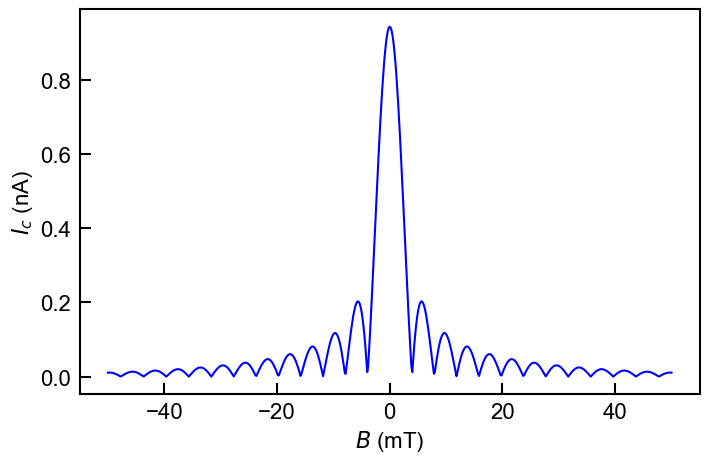

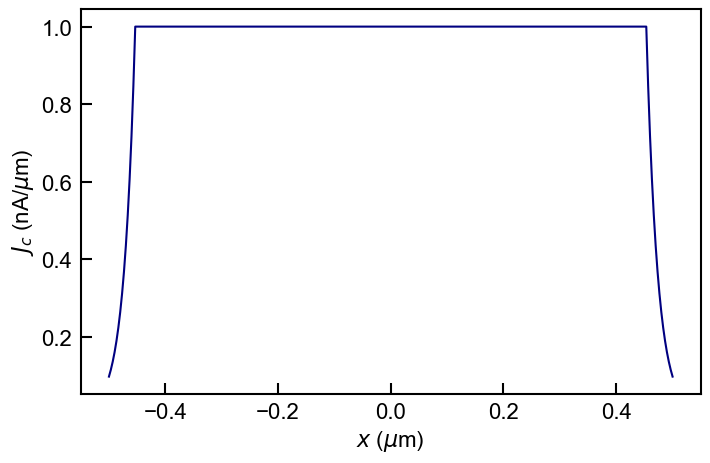

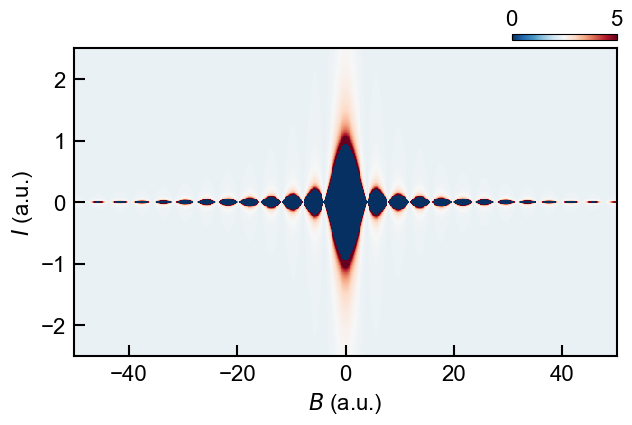

In [971]:
'''
Code to generate the actual integral, which would be the measured Ic(B)
'''
integral=[]

x=np.linspace(-0.5,0.5,601)
B=np.linspace(-50,50,601)

V=np.linspace(-2.5,2.5,401)
DOSV=np.zeros((len(V),len(B)))

I_asym=True
t=1/1.8
l=0.05
edge_l=0.15
edge_l2=0.15
ratio=0
jc1=1
jc2=4
edgeratio=0.4

Jsx=square_exp(x,l,50)

phase1=0
phase2=0
phase3=0

'''For the maps'''
Icplus=[]
Icminus=[]

# This is an integral in x, so I run everything over B
for i in B:
    
    ## Obtain the complex current density 
    int_trap_plus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l+l,l,phase1,phase2,phase3,t),x)
    mod_plus=cmath.sqrt((int_trap_plus.real)**2+(int_trap_plus.imag)**2)
    Icplus.append( mod_plus)  
    
    if I_asym: # Do we add the curren phase asymmetry or not 
        int_trap_minus=np.trapz(int_Js_brokenT(Jsx,i,x,edge_l,l,-phase1,-phase2,-phase3,t),x)
        mod_minus=cmath.sqrt((int_trap_minus.real)**2+(int_trap_minus.imag)**2) 
        Icminus.append( mod_minus )
    else:
        Icminus.append(mod_plus)

## Plot the results 
ax=plot_pre()
ax.plot(B,Icplus,'b')
plot_line(ax,leg=False)
#ax.text(40,0.33,r'$\beta_{left}=L(B+)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.3,r'$\beta_{right}=L(B)/\Phi_0$',fontsize=font-2)
#ax.text(40,0.27,r'$\beta_{bulk}=L(B)/\Phi_0$',fontsize=font-2)
#ax.axvline(x=0,linestyle='dashed')
plt.show()

ax=plot_pre()
#ax.plot(x,Jsx,'navy')
ax.plot(x,Jsx,'navy')
#ax.axvline(x=x[0]+edge_l+l)
plot_line(ax,xlabel='$x$ ($\mu$m)',ylabel='$J_c$ (nA/$\mu$m)',leg=False)
plt.show()

'''Code for the maps'''

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)


fig=plt.figure(figsize=(7,4))
ax=fig.add_subplot(111)
im=plt.pcolormesh(B,V,Ns2D_IAsym(V,Icplus,Icminus)/15,cmap='RdBu_r',vmax=5,rasterized=True)

ax.set_ylabel('$I$ (a.u.)',fontsize=font)
ax.set_xlabel('$B$ (a.u.)',fontsize=font)  
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=6,size=8,width=1.5)
ax.tick_params(axis='both',which='minor',direction='in',size=4,width=1.5)
#ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
#ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(20))
#ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
#ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(50))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
if save:
    plt.savefig(savename+'EdgeBulk_Fraunhofer'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    plt.savefig(savename+'EdgeBulk_Fraunhofer'+time.strftime("%H%M%d%m%y")+'.pdf') 
    savecount=savecount+1    
plt.show()

## Phenomenological models

[340]
[300]
[300]
[340]


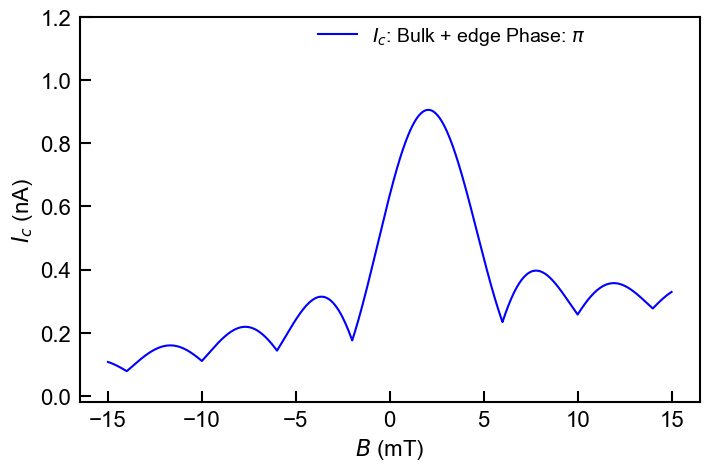

In [120]:

int_x=np.linspace(y[-1,0],y[0,0],601)
int_Icposnorm=np.interp(int_x,np.flip(y[:,0]),np.flip(Icpos_norm)/np.amax(Icpos_norm))

wbulk=0.7
wsq=0
wedge=1-wbulk-wsq
fbulk=0.25
fedge=0.02
fsq=0.13
phi1=0
phi2=0
phase1=-np.pi/2
phase2=-np.pi/2
phase3=-np.pi/2
phase4=-np.pi/2
phase5=-np.pi/2

Frju1=magnJJ_bulkedge(int_x,wbulk,wedge,wsq,fbulk,fedge,fsq,phi1,phi2,
                      phase1,phase2,phase3,phase4,phase5)
Frnomag=magnJJ_bulkedge(int_x,wbulk,wedge,wsq,fbulk,fedge,fsq,phi1,phi2,
                      0,0,0,0,0)
FrnomagnoSQ=magnJJ_bulkedge(int_x,0.75,0.25,0,fbulk,fedge,fsq,phi1,phi2,
                      0,0,0,0,0)
FrnoSQ=magnJJ_bulkedge(int_x,0.7,0.3,0,fbulk,fedge,fsq,phi1,phi2,
                      phase1,phase2,phase3,phase4,phase5)

ax=plot_pre(8,5)
ax.plot(int_x,Frju1,'b',label='$I_c$: Bulk + edge Phase: $\pi$')
#ax.plot(int_x,Frnomag,'k--',label='$I_c$: Bulk + edge')
#plt.plot(sm_x,fit_func(sm_x,a,b,c,d,e,f))
#ax.plot(int_x,int_Icposnorm,'b-',label=r'Data Max. 35 mK $I_{+}$-0.5')

plot_line(ax,legx=0.6,legy=1.025,font_size=16,font_leg=2)
ax.set_ylim(-0.02,1.2)

plt.show()


In [ ]:

ax=plot_pre(8,5)
ax.plot(int_x,FrnoSQ,'r',label='Model:0.7xbulk + 0.2xedge+0.1 SQUID')
ax.plot(int_x,int_Icposnorm,'b-',label=r'Data Max. 35 mK $I_{+}$-0.5')
plot_line(ax,legx=0.4,legy=1.025,font_size=16,font_leg=2)
#ax.plot(y[:,0],Icpos_norm,'b-',label=r'Data Max. 35 mK $I_{+}$-0.5')
ax.set_ylim(-0.02,1.2)

plt.show()

ax=plot_pre(8,5)
ax.plot(int_x,FrnomagnoSQ,'r',label='Model (no Mag): 0.75 Bulk + 0.25 Edge')
#ax.plot(int_x,FrnoSQ,'k--',label='Model:0.75xbulk + 0.25')
ax.plot(int_x,int_Icposnorm,'b-',label=r'Data Max. 35 mK $I_{+}$-0.5')
plot_line(ax,legx=0.4,legy=1.025,font_size=16,font_leg=2)
ax.set_ylim(-0.02,1.2)

plt.show()

## Phenomenological Model by Yingming 

Text(0, 0.5, 'I_c/I_{c,max}')

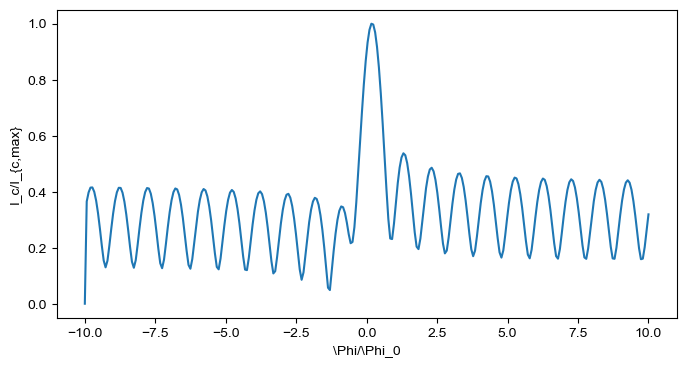

In [222]:
I1=0.1
I2=0.2
I3=0.5
## I1, I2 edge, I3 Bulk
varphi1=0;
varphi2=np.pi/2;
varphi3=np.pi/2
def Current(x,phi):
    return I1*np.sin(phi+np.pi*x+varphi1)+I2*np.sin(phi-np.pi*x+varphi2)+I3*np.sin(np.pi*x)/(np.pi*x)*np.sin(phi); # x flux quantum

phi=np.linspace(0,2*np.pi,100);

x=np.linspace(-10,10,300)

Ic_p=np.zeros_like((x))
for i in range(1,len(x)):
    Ic_p[i]=np.amax(Current(x[i],phi))

plt.figure(figsize=(8,4))
plt.plot(x,Ic_p/np.amax(Ic_p))
plt.xlabel('\Phi/\Phi_0')
plt.ylabel('I_c/I_{c,max}')

## Modifying Yingming´s model

In [236]:
100E-9*500E-9

4.9999999999999995e-14

In [237]:
5E-6*5E-6

2.5000000000000004e-11

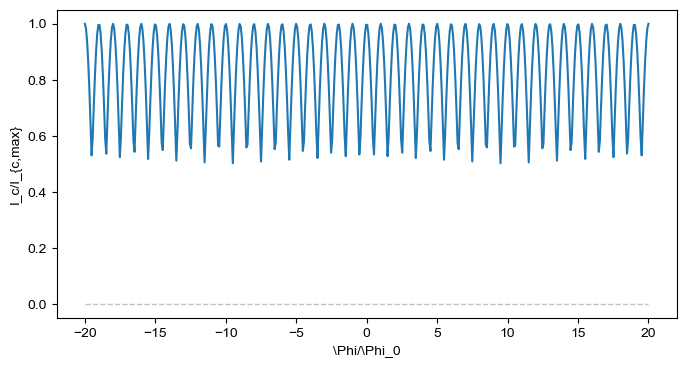

In [244]:

I1=0.2
I2=0.2
I3=0
I4=0.2
I5=0.2
## I1, I2 edge, I3 Bulk
varphi1=0
varphi2=0
varphi3=0
edge_ratio=1000
def Current(x,phi):
    edge1=I1*np.sin(phi+np.pi*x+varphi1)
    edge2=I2*np.sin(phi-np.pi*x+varphi2)
    bulk=np.abs(I3*np.sin(np.pi*x+varphi3)/(np.pi*x+varphi3))
    edgeJJ1=np.abs(I4*np.sin(np.pi*x/edge_ratio+varphi3)/(np.pi*x/edge_ratio+varphi3))
    edgeJJ2=np.abs(I5*np.sin(np.pi*x/edge_ratio+varphi3)/(np.pi*x/edge_ratio+varphi3))
    
    return edge1+edge2+bulk+edgeJJ1+edgeJJ2; # x flux quantum

#phi=np.linspace(0,2*np.pi,100);

x=np.linspace(-20,20,500)

Ic_p=np.zeros_like((x))
for i in range(0,len(x)):
    Ic_p[i]=np.amax(Current(x[i],phi))
    

plt.figure(figsize=(8,4))
plt.plot(x,Ic_p/np.amax(Ic_p))
plt.xlabel('\Phi/\Phi_0')
plt.ylabel('I_c/I_{c,max}')
plt.plot(x,x*0+0,linestyle="dashed",linewidth=1,color='silver')